# Tabular ResNet Optimized & Regularized - PS-S06E08

This notebook implements an optimized and regularized Tabular ResNet model in PyTorch for **Playground Series – Season 6, Episode 8: Predicting Smartphone Addiction**.

To combat overfitting, we employ a smaller network capacity (hidden_dim=128, num_blocks=2), strong regularization (dropout=0.4, weight_decay=1e-2), and average predictions across multiple seeds using 5-Fold cross-validation.

## 1. Setup & Imports

In [1]:
import os
import gc
import sys
import copy
import math
import random
import warnings
from pathlib import Path

# --- Third-party
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score

from ps_s06e08_experiment_setup import ExperimentSetup
from ps_s06e08_feature_engineering import FeatureFactory
from ps_s06e08_model_visualizer import ModelVisualizer

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on device: {device}")

Training on device: cuda


In [2]:
setup = ExperimentSetup(
    model_name='NN_TabularResNet',
    use_gpu=torch.cuda.is_available(),
    perform_rfe=False,
    perform_optuna_tuning=False
)

setup.configure_pandas()
setup.suppress_warnings()

TARGET = 'addicted_label'

Warnings suppressed.


## 2. Load Datasets

In [3]:
training_df = setup.read_dataset('training')
train_ids = training_df['id'].copy()

test_df = setup.read_dataset('test')
test_ids = test_df['id'].copy()

TRAINING DATASET

   id    age  daily_screen_time_hours  social_media_hours  gaming_hours  \
0   0 24.000                      NaN               1.830         1.590   
1   1 19.000                    5.970               1.080           NaN   
2   2 18.000                    5.090                 NaN           NaN   
3   3 21.000                    6.420               1.260         1.420   
4   4 26.000                   11.200               1.870         2.810   

   work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  \
0             2.110        7.460                122.000             38.000   
1             3.030        8.220                 76.000             19.000   
2               NaN        6.250                134.000             60.000   
3             3.360        8.850                112.000             94.000   
4             1.950        5.250                    NaN                NaN   

   weekend_screen_time  gender stress_level academic_work_impa

TEST DATASET

       id    age  daily_screen_time_hours  social_media_hours  gaming_hours  \
0  691369 30.000                    9.340                 NaN         0.770   
1  691370    NaN                      NaN               1.910           NaN   
2  691371 26.000                    8.480               3.640           NaN   
3  691372 20.000                    8.370               2.990         1.690   
4  691373 25.000                    8.250               4.020         1.210   

   work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  \
0             4.090        7.150                153.000             16.000   
1             1.200        8.670                239.000            148.000   
2             3.390        7.470                106.000            123.000   
3             2.530        5.450                178.000             55.000   
4             2.320        8.460                 63.000             86.000   

   weekend_screen_time  gender stress_leve

## 3. Feature Engineering

In [4]:
fe_strategies = [
    'encoding',
    'screen_time_ratios',
    'sleep_stress',
    'risk_score',
    'missing_flags',
    'numeric_expansion'
]

print('Performing feature engineering (all engineered features)...')
factory = FeatureFactory(
    strategies=fe_strategies,
    impute_strategy='median_mode',
    target=TARGET,
    verbose=True
)

y = training_df[TARGET].copy()

X = factory.fit_transform(training_df)
X_test = factory.transform(test_df)

print(f'Train features shape: {X.shape}')
print(f'Test features shape: {X_test.shape}')

Performing feature engineering (all engineered features)...
  -> Fitting DataFrame...


Applying FeatureFactory with strategies: encoding, screen_time_ratios, sleep_stress, risk_score, missing_flags, numeric_expansion
  -> Imputing missing values using learned medians and modes...


  -> Adding missing flags...
  -> Encoding categorical variables...
  -> Adding screen time ratio features...


  -> Adding sleep_stress interaction features...
  -> Adding lifestyle risk score features...


  -> Adding numeric expansion features...
Applying FeatureFactory with strategies: encoding, screen_time_ratios, sleep_stress, risk_score, missing_flags, numeric_expansion


  -> Imputing missing values using learned medians and modes...
  -> Adding missing flags...
  -> Encoding categorical variables...
  -> Adding screen time ratio features...
  -> Adding sleep_stress interaction features...


  -> Adding lifestyle risk score features...
  -> Adding numeric expansion features...


Train features shape: (691369, 69)
Test features shape: (296302, 69)


## 4. PyTorch Dataset & Encoders Setup

In [5]:
class TabularDataset(Dataset):
    def __init__(self, x_num, x_cat, y=None):
        self.x_num = torch.FloatTensor(x_num)
        self.x_cat = torch.LongTensor(x_cat)
        self.y = torch.LongTensor(y) if y is not None else None

    def __len__(self):
        return len(self.x_num)

    def __getitem__(self, idx):
        if self.y is not None:
            return self.x_num[idx], self.x_cat[idx], self.y[idx]
        return self.x_num[idx], self.x_cat[idx]

In [6]:
def fit_nn_encoders(X_train, X_test, cat_cols):
    X_all = pd.concat([X_train[cat_cols], X_test[cat_cols]], axis=0, ignore_index=True)
    
    cat_maps = {}
    cat_dims = []
    for c in cat_cols:
        s = X_all[c].astype(str).fillna("__nan__")
        uniq = pd.Index(s.unique())
        cat_maps[c] = {k: i for i, k in enumerate(uniq)}
        cat_dims.append(len(uniq))
        
    num_cols = [c for c in X_train.columns if c not in cat_cols]
    return {
        "cat_cols": cat_cols,
        "num_cols": num_cols,
        "cat_maps": cat_maps,
        "cat_dims": cat_dims
    }

def transform_with_encoders(X, fitted):
    cat_cols = fitted["cat_cols"]
    num_cols = fitted["num_cols"]
    cat_maps = fitted["cat_maps"]
    
    X_num = X[num_cols].to_numpy(dtype=np.float32)
    
    X_cat = np.zeros((len(X), len(cat_cols)), dtype=np.int64)
    for j, c in enumerate(cat_cols):
        m = cat_maps[c]
        s = X[c].astype(str).fillna("__nan__")
        X_cat[:, j] = s.map(lambda v: m.get(v, 0)).to_numpy(dtype=np.int64)
        
    return X_num, X_cat

## 5. Model Architecture

In [7]:
class ResNetBlock(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate):
        super(ResNetBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, input_dim),
            nn.BatchNorm1d(input_dim)
        )
        self.activation = nn.GELU()

    def forward(self, x):
        return self.activation(x + self.block(x))


class TabularResNet(nn.Module):
    def __init__(self, num_dim, cat_dims, n_classes=2, hidden_dim=128, dropout_rate=0.4, num_blocks=2):
        super(TabularResNet, self).__init__()

        # Embedding layers for categoricals
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_cats, emb_dim)
            for num_cats, emb_dim in cat_dims
        ])

        total_cat_dim = sum(emb_dim for _, emb_dim in cat_dims)
        combined_dim = num_dim + total_cat_dim

        self.input_layer = nn.Linear(combined_dim, hidden_dim)
        self.bn0 = nn.BatchNorm1d(hidden_dim)

        self.blocks = nn.ModuleList([
            ResNetBlock(hidden_dim, hidden_dim, dropout_rate)
            for _ in range(num_blocks)
        ])

        # Output head mapping to n_classes logits
        self.output_head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Linear(64, n_classes)
        )

    def forward(self, x_num, x_cat):
        embedded_cats = [
            emb_layer(x_cat[:, i])
            for i, emb_layer in enumerate(self.embeddings)
        ]
        if embedded_cats:
            x = torch.cat(embedded_cats + [x_num], dim=1)
        else:
            x = x_num
        x = self.input_layer(x)
        x = self.bn0(x)
        for block in self.blocks:
            x = block(x)
        return self.output_head(x)

## 6. Training & Validation Loop

Trains the model across 5 Stratified CV folds and averages predictions over multiple seeds to reduce prediction variance.

In [8]:
BATCH_SIZE = 4096
EPOCHS = 150
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-2
ES_PATIENCE = 20
n_splits = 5

seeds = setup.seed()
oof_probs = np.zeros((len(X), 2))
test_probs = np.zeros((len(X_test), 2))
filled_mask = np.zeros(len(X), dtype=bool)

for seed_idx, run_seed in enumerate(seeds):
    print(f"\n{'='*20} SEED {run_seed} ({seed_idx+1}/{len(seeds)}) {'='*20}")
    setup.set_seeds(run_seed)
    torch.manual_seed(run_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(run_seed)
        
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=run_seed)
    
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"\n--- Seed {run_seed} | Fold {fold+1}/{n_splits} ---")
        
        X_tr_df, y_tr = X.iloc[tr_idx].copy(), y.iloc[tr_idx].values
        X_val_df, y_val = X.iloc[val_idx].copy(), y.iloc[val_idx].values
        
        cat_features = factory.get_cat_features(X_tr_df)
        fitted = fit_nn_encoders(X_tr_df, X_test, cat_features)
        
        Xtr_num_np, Xtr_cat_np = transform_with_encoders(X_tr_df, fitted)
        Xva_num_np, Xva_cat_np = transform_with_encoders(X_val_df, fitted)
        Xte_num_np, Xte_cat_np = transform_with_encoders(X_test, fitted)
        
        # Imputation & Scaling
        imputer = SimpleImputer(strategy='median')
        Xtr_num_np = imputer.fit_transform(Xtr_num_np)
        Xva_num_np = imputer.transform(Xva_num_np)
        Xte_num_np = imputer.transform(Xte_num_np)
        
        scaler = StandardScaler()
        Xtr_num_np = scaler.fit_transform(Xtr_num_np)
        Xva_num_np = scaler.transform(Xva_num_np)
        Xte_num_np = scaler.transform(Xte_num_np)
        
        cat_dims = [(n, min(16, int(np.ceil(np.sqrt(n))))) for n in fitted["cat_dims"]]
        num_dim = Xtr_num_np.shape[1]
        
        train_ds = TabularDataset(Xtr_num_np, Xtr_cat_np, y_tr)
        val_ds = TabularDataset(Xva_num_np, Xva_cat_np, y_val)
        
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
        
        model = TabularResNet(
            num_dim=num_dim,
            cat_dims=cat_dims,
            n_classes=2,
            hidden_dim=128,
            num_blocks=2,
            dropout_rate=0.4
        ).to(device)
        
        optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
        scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)
        
        best_val_auc = -1.0
        best_model_weights = copy.deepcopy(model.state_dict())
        patience_counter = 0
        prev_lr = LEARNING_RATE
        
        for epoch in range(EPOCHS):
            model.train()
            running_loss = 0.0
            
            for batch_num, batch_cat, batch_y in train_loader:
                batch_num, batch_cat, batch_y = batch_num.to(device), batch_cat.to(device), batch_y.to(device)
                
                optimizer.zero_grad()
                logits = model(batch_num, batch_cat)
                loss = criterion(logits, batch_y)
                loss.backward()
                optimizer.step()
                
                running_loss += loss.item() * batch_num.size(0)
                
            epoch_loss = running_loss / len(train_loader.dataset)
            
            # Evaluation
            model.eval()
            val_preds_list = []
            val_targets_list = []
            
            with torch.no_grad():
                for batch_num, batch_cat, batch_y in val_loader:
                    batch_num, batch_cat = batch_num.to(device), batch_cat.to(device)
                    logits = model(batch_num, batch_cat)
                    probs = torch.softmax(logits, dim=1)[:, 1]
                    val_preds_list.extend(probs.cpu().numpy())
                    val_targets_list.extend(batch_y.numpy())
                    
            val_auc = roc_auc_score(val_targets_list, val_preds_list)
            current_lr = optimizer.param_groups[0]['lr']
            scheduler.step()
            
            if (epoch + 1) % 10 == 0 or epoch == 0:
                print(f"    Epoch {epoch+1:03d} | Loss: {epoch_loss:.4f} | Val ROC AUC: {val_auc:.6f} | LR: {current_lr:.6f}")
                
            # Early stopping check
            if val_auc > best_val_auc:
                best_val_auc = val_auc
                best_model_weights = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                if current_lr > prev_lr * 2:
                    patience_counter = 0
                if epoch >= 15 and current_lr < 0.2 * LEARNING_RATE:
                    patience_counter += 1
                    if patience_counter >= ES_PATIENCE:
                        print(f"    Early stopping at epoch {epoch+1} (Best Val AUC: {best_val_auc:.6f})")
                        break
                        
            prev_lr = current_lr
            
        # Fold inference
        model.load_state_dict(best_model_weights)
        model.eval()
        with torch.no_grad():
            val_num_t = torch.tensor(Xva_num_np, dtype=torch.float32).to(device)
            val_cat_t = torch.tensor(Xva_cat_np, dtype=torch.long).to(device)
            val_logits = model(val_num_t, val_cat_t)
            val_probs = torch.softmax(val_logits, dim=1).cpu().numpy()
            
            oof_probs[val_idx] += val_probs / len(seeds)
            filled_mask[val_idx] = True
            
            te_num_t = torch.tensor(Xte_num_np, dtype=torch.float32).to(device)
            te_cat_t = torch.tensor(Xte_cat_np, dtype=torch.long).to(device)
            te_logits = model(te_num_t, te_cat_t)
            te_probs = torch.softmax(te_logits, dim=1).cpu().numpy()
            
            test_probs += te_probs / (n_splits * len(seeds))
            
        print(f"    Fold {fold+1} ROC AUC: {best_val_auc:.6f}")

overall_score = roc_auc_score(y[filled_mask], oof_probs[filled_mask, 1])
print("\n" + "="*60)
print(f"Overall Seed-Averaged CV ROC AUC: {overall_score:.6f}")
print("="*60)


==================== SEED 10301 (1/5) ====================
Random seed set to: 10301

--- Seed 10301 | Fold 1/5 ---


    Epoch 001 | Loss: 0.3742 | Val ROC AUC: 0.932662 | LR: 0.001000


    Epoch 010 | Loss: 0.3444 | Val ROC AUC: 0.936574 | LR: 0.000025


    Epoch 020 | Loss: 0.3423 | Val ROC AUC: 0.937451 | LR: 0.000579


    Epoch 030 | Loss: 0.3397 | Val ROC AUC: 0.938142 | LR: 0.000007


...

    Epoch 120 | Loss: 0.3330 | Val ROC AUC: 0.938286 | LR: 0.000328


    Epoch 130 | Loss: 0.3318 | Val ROC AUC: 0.938145 | LR: 0.000161


    Epoch 140 | Loss: 0.3309 | Val ROC AUC: 0.938200 | LR: 0.000047


    Early stopping at epoch 147 (Best Val AUC: 0.939273)
    Fold 5 ROC AUC: 0.939273



Overall Seed-Averaged CV ROC AUC: 0.939631


## 7. Performance Visualization

<Figure size 800x600 with 0 Axes>

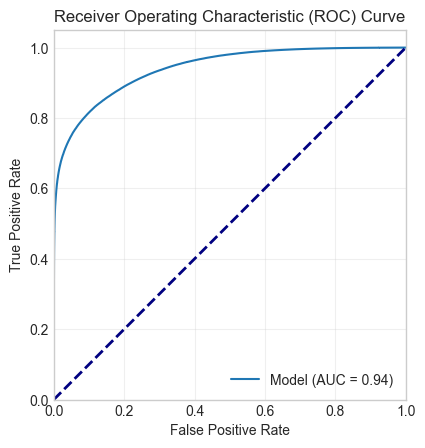

In [9]:
mviz = ModelVisualizer(model_name='NN_TabularResNet')
mviz.plot_roc_curve(y_true=y[filled_mask], y_score=oof_probs[filled_mask, 1])

Confusion matrix, without normalization


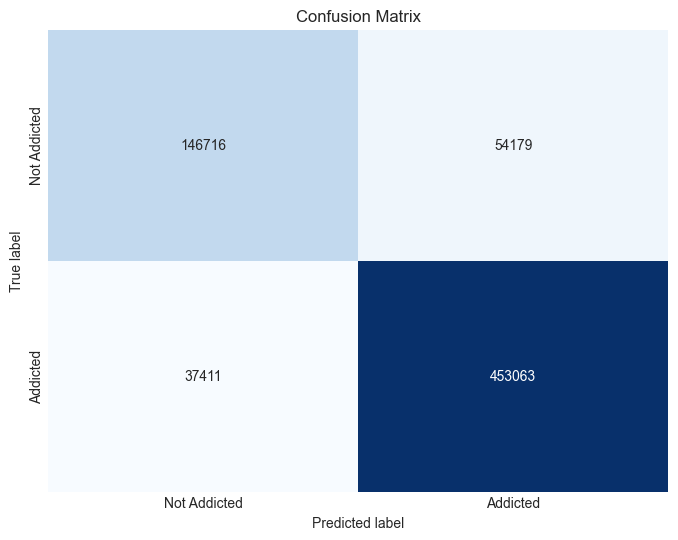

In [10]:
y_pred_class = (oof_probs[:, 1] > 0.5).astype(int)
mviz.plot_confusion_matrix(
    y_true=y[filled_mask],
    y_pred=y_pred_class[filled_mask],
    classes=['Not Addicted', 'Addicted']
)

## 8. Export Submission & Predictions

In [11]:
submission_df = setup.read_dataset('submission')
submission_df['addicted_label'] = test_probs[:, 1]
submission_df.to_csv('submission.csv', index=False)
print("Saved submission.csv successfully!")

Saved submission.csv successfully!


In [12]:
setup.save_probabilities('nn', oof_probs, train_ids, y, filled_mask, test_probs, test_ids)

Saved for ensembling:
 - predictions/nn_oof_probs.csv
 - predictions/nn_test_probs.csv
